# Approximate segmentation through tile prediction

Identifying tissue structures in histopathology images is typically challenging due to sparse annotations required to train segmentation models. However, we can approximate the segmentation problem by transforming it into a tile prediction task on small image patches. This approach allows us to leverage the power of foundation models to train effective tile prediction models with minimal annotations. An additional benefit is that training such models can be accomplished easily without requiring a GPU.

This tutorial demonstrates how to use LazySlide and wsidata to construct a tile prediction model based on extracted tile features.

## Dataset

For this tutorial, we'll use GTEx Stomach slides with pre-existing annotations. You can create annotations using QuPath or other annotation tools and import them into wsidata as a GeoDataFrame. These annotations can then be used to label the tiles.

Here's an example workflow:

```python
from wsidata import open_wsi
import lazyslide as zs

slide_path = "my_wsi.svs"
annotations = "anno.geojson"  # Annotation exported from QuPath

wsi = open_wsi(slide_path)  # Open the WSI
zs.pp.find_tissues(wsi)
zs.pp.tile_tissues(wsi, 128)

zs.io.load_annotations(wsi, annotations)  # Load annotations into wsidata

# Use spatial join to label tiles - adjust code based on your table content
wsi['tiles'] = wsi['tiles'].sjoin(wsi['annotations'])
```

For this tutorial, we've prepared an example dataset containing slides for training and evaluation, plus additional slides for inference testing. This ensures that our model can demonstrate real generalization capabilities.

In [1]:
from pathlib import Path
import zipfile

from huggingface_hub import hf_hub_download

hf_hub_download(
    "RendeiroLab/LazySlide-data",
    "gtex_stomach_subset.zip",
    repo_type="dataset",
    local_dir="datasets",
)

zip_path = "datasets/gtex_stomach_subset.zip"
extract_dir = Path("datasets")

if not (extract_dir / "gtex-stomach-subset").exists():
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

gtex_stomach_subset.zip:   0%|          | 0.00/15.4G [00:00<?, ?B/s]

Let's explore the dataset structure:

In [2]:
from rich.console import Console
from rich.tree import Tree


def make_tree(path: Path, tree: Tree, level: int = 0, max_depth: int = None):
    """Recursively build tree from directory structure with depth control."""
    if max_depth is not None and level >= max_depth:
        return
    for p in sorted(path.iterdir()):
        if p.is_dir():
            branch = tree.add(f"[bold blue]{p.name}/[/]")
            make_tree(p, branch, level + 1, max_depth)
        else:
            tree.add(p.name)


def show_folder_tree(root_dir: str, max_depth: int = None):
    console = Console()
    root_path = Path(root_dir)
    tree = Tree(f"[bold magenta]{root_path.name}/[/]")
    make_tree(root_path, tree, level=0, max_depth=max_depth)
    console.print(tree)


show_folder_tree("datasets/gtex-stomach-subset", max_depth=2)

gtex-stomach-subset/
├── test/
│   ├── GTEX-1JJE9-2026.svs
│   ├── GTEX-1JJE9-2026.zarr/
│   ├── GTEX-Y111-2526.svs
│   └── GTEX-Y111-2526.zarr/
└── train/
    ├── GTEX-111FC-2126.zarr/
    ├── GTEX-11GS4-1626.zarr/
    ├── GTEX-11PRG-1826.zarr/
    ├── GTEX-11WQK-2626.zarr/
    ├── GTEX-11ZTT-1926.zarr/
    ├── GTEX-11ZVC-1926.zarr/
    ├── GTEX-12WSI-1326.zarr/
    ├── GTEX-12ZZW-2226.zarr/
    ├── GTEX-13111-1226.zarr/
    ├── GTEX-1339X-1426.zarr/
    ├── GTEX-139YR-1926.zarr/
    ├── GTEX-13CZV-2426.zarr/
    ├── GTEX-13N1W-2026.zarr/
    ├── GTEX-13NYB-1426.zarr/
    ├── GTEX-13NZ9-2326.zarr/
    ├── GTEX-13OVL-2826.zarr/
    ├── GTEX-13SLX-2026.zarr/
    ├── GTEX-13W3W-1926.zarr/
    ├── GTEX-14A6H-1626.zarr/
    ├── GTEX-14BIL-1926.zarr/
    ├── GTEX-14BIM-1526.zarr/
    ├── GTEX-14C5O-2426.zarr/
    ├── GTEX-14E6E-0926.zarr/
    ├── GTEX-14PJ3-1426.zarr/
    ├── GTEX-15FZZ-1426.zarr/
    ├── GTEX-15TU5-2526.zarr/
    ├── GTEX-17MF6-2126.zarr/
    ├── GTEX-18D9A-0626.zarr/
    ├── GTEX-1A3MV-1226.zarr/
    ├── GTEX-1A3MW-2326.zarr/
    ├── GTEX-1A3MX-1926.zarr/
    ├── GTEX-1AYCT-1326.zarr/
    ├── GTEX-1C6WA-1726.zarr/
    ├── GTEX-1CB4F-1626.zarr/
    ├── GTEX-1EH9U-2226.zarr/
    ├── GTEX-1EX96-2426.zarr/
    ├── GTEX-1F75W-2826.zarr/
    ├── GTEX-1HFI7-1526.zarr/
    ├── GTEX-1HSGN-2026.zarr/
    ├── GTEX-1I19N-2526.zarr/
    ├── GTEX-1IKJJ-2626.zarr/
    ├── GTEX-1J1OQ-2626.zarr/
    ├── GTEX-1JKYR-1526.zarr/
    ├── GTEX-1JMPY-0926.zarr/
    ├── GTEX-1MCC2-1726.zarr/
    ├── GTEX-1N2EE-2626.zarr/
    ├── GTEX-1O97I-1926.zarr/
    ├── GTEX-1OJC4-1926.zarr/
    ├── GTEX-1S83E-1126.zarr/
    ├── GTEX-O5YU-1926.zarr/
    ├── GTEX-OHPM-1526.zarr/
    ├── GTEX-OHPN-2126.zarr/
    ├── GTEX-P4QR-1926.zarr/
    ├── GTEX-PWO3-1926.zarr/
    ├── GTEX-R3RS-1926.zarr/
    ├── GTEX-RN64-1926.zarr/
    ├── GTEX-RWS6-0926.zarr/
    ├── GTEX-UPJH-2426.zarr/
    ├── GTEX-XBED-1226.zarr/
    ├── GTEX-XMK1-1526.zarr/
    ├── GTEX-XUZC-0726.zarr/
    ├── GTEX-ZF3C-2426.zarr/
    ├── GTEX-ZU9S-2526.zarr/
    ├── GTEX-ZXG5-2626.zarr/
    └── GTEX-ZYT6-1826.zarr/

All zarr files contain wsidata with features extracted using `virchow2` and an annotation column named `domain` in the tile table.

To train your own model, you'll need to prepare two key components:
- **Feature extraction**: Run feature extraction on all slides
- **Tile annotations**: Prior annotations on the tiles

wsidata provides a `FeaturesDatasetBuilder` that handles all the complex work during dataset preparation, including data balancing and data splitting.

In [3]:
from wsidata.dataset import FeaturesDatasetBuilder

stores = list((extract_dir / "gtex-stomach-subset" / "train").glob("*.zarr"))

builder = FeaturesDatasetBuilder(
    stores,
    tile_key="tiles",
    feature_key="virchow2",
    target_key="domain",
    skip_class=["artifact"],
    sampler="undersample",
    in_memory=True,  # Set to False if your dataset cannot fit into RAM, IterableDataset will be used instead
)

/usr/lib/python3.12/importlib/__init__.py:90: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  return _bootstrap._gcd_import(name[level:], package, level)


/home/runner/work/lazyslide-tutorials/lazyslide-tutorials/.venv/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


/home/runner/work/lazyslide-tutorials/lazyslide-tutorials/.venv/lib/python3.12/site-packages/wsidata/dataset/multislides/builder.py:106: UserWarning: It looks like the target column contains NaN values. The NaN rows will be removed.
  warnings.warn(


Now let's split the dataset into training, validation, and test sets:

In [4]:
ds = builder.split(val=0.2, test=0.1)
ds

{'train': <wsidata.dataset.multislides.dataset.CachedFeaturesDataset at 0x7fb20328f2f0>,
 'test': <wsidata.dataset.multislides.dataset.CachedFeaturesDataset at 0x7fb20383cf80>,
 'val': <wsidata.dataset.multislides.dataset.CachedFeaturesDataset at 0x7fb20328d5b0>}

With our dataset prepared, we can begin model training. Since everyone has their own preferences for training approaches, we'll demonstrate an easy method using the Lightning framework.

For this showcase, we'll define a simple 2-layer network. In real-world applications, you may want to consider more complex network architectures.

Since we're tackling a multi-class classification task, our setup includes:
- **Loss function**: Cross-entropy
- **Evaluation metrics**: Accuracy and F1 score
- **Optimizer**: AdamW

In [5]:
import torch
from torch import nn, utils
import lightning as L
from torchmetrics import Accuracy, F1Score

in_dims = 2560  # Feature dimension of Virchow2
n_class = 5  # Number of classes in the dataset
model = nn.Sequential(
    nn.Linear(in_dims, 64), nn.ReLU(), nn.Linear(64, n_class)
)  # Simple 2-layer network

Next, we'll set up the Lightning framework for model training:

In [6]:
# Define the LightningModule
class LitModel(L.LightningModule):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.loss = (
            nn.CrossEntropyLoss()
        )  # Loss function for multi-class classification
        self.acc = Accuracy(task="multiclass", num_classes=n_class)
        self.f1 = F1Score(task="multiclass", num_classes=n_class)

    def training_step(self, batch, batch_idx):
        pred = self.model(batch["feature"])
        y = batch["target"]
        loss = self.loss(pred, y)
        acc = self.acc(pred, y)
        f1 = self.f1(pred, y)

        # Logging to TensorBoard (if installed) by default
        self.log("train_loss", loss, on_epoch=True)
        self.log("train_acc", acc, on_epoch=True)
        self.log("train_f1", f1, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        # Validation loop
        pred = self.model(batch["feature"])
        y = batch["target"]
        val_loss = self.loss(pred, y)
        acc = self.acc(pred, y)
        f1 = self.f1(pred, y)
        self.log("val_loss", val_loss, on_epoch=True, prog_bar=True)
        self.log("val_acc", acc, on_epoch=True, prog_bar=True)
        self.log("val_f1", f1, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        # Test loop
        pred = self.model(batch["feature"])
        y = batch["target"]
        val_loss = self.loss(pred, y)
        acc = self.acc(pred, y)
        f1 = self.f1(pred, y)
        self.log("test_loss", val_loss, on_epoch=True, prog_bar=True)
        self.log("test_acc", acc, on_epoch=True, prog_bar=True)
        self.log("test_f1", f1, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=1e-4)

Let's wrap our dataset in DataLoaders. Since this is an in-memory dataset, **avoid using multiple workers** in the DataLoader:

If you set `in_memory=False` in the dataset builder, it will return an IterableDataset. In such case, please use multiple workers.

In [7]:
train_loader = utils.data.DataLoader(ds["train"], batch_size=2000)
val_loader = utils.data.DataLoader(ds["val"], batch_size=2000)
test_loader = utils.data.DataLoader(ds["test"], batch_size=2000)

In [8]:
lit_model = LitModel(model)
trainer = L.Trainer(max_epochs=5)
trainer.fit(model=lit_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(model=lit_model, dataloaders=test_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


/home/runner/work/lazyslide-tutorials/lazyslide-tutorials/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


...

`Trainer.fit` stopped: `max_epochs=5` reached.


/home/runner/work/lazyslide-tutorials/lazyslide-tutorials/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.7197740077972412     │
│          test_f1          │    0.7197740077972412     │
│         test_loss         │    0.7493443489074707     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.7493443489074707,
  'test_acc': 0.7197740077972412,
  'test_f1': 0.7197740077972412}]

The model should train in just a few seconds. Here we achieved a test accuracy of >0.7, which is sufficient for inference demonstration.

**Tips to improve performance:**
- Increase training data volume
- Experiment with better network architectures
- Tune hyperparameters systematically
- Apply data augmentation techniques
- Use ensemble methods

Let's evaluate our model's performance visually using a slide that wasn't included in the training or evaluation sets.

Note: In this example dataset, feature extraction has already been completed for you.

In [9]:
from wsidata import open_wsi

test1 = open_wsi("datasets/gtex-stomach-subset/test/GTEX-1JJE9-2026.svs")

version mismatch: detected: RasterFormatV02, requested: FormatV04


/home/runner/work/lazyslide-tutorials/lazyslide-tutorials/.venv/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


In [10]:
# Let's get the mapping between class names and indices
mapping = {v: k for k, v in ds["train"].targets_mapping.items()}
mapping

{0: 'gastric foveolae',
 1: 'gastric glands',
 2: 'hemorrhage',
 3: 'muscularis',
 4: 'submucosa'}

We can run inference directly on the feature space with a single forward pass:

In [11]:
# Run inference
with torch.inference_mode():
    feature_matrix = torch.tensor(test1["virchow2_tiles"].X)
    tile_labels = model(feature_matrix).softmax(1).argmax(1)

# Map predicted labels back to class names
test1["tiles"]["infer_domain"] = [mapping[int(i)] for i in tile_labels]

Now let's visualize both the ground truth and our predictions for comparison:

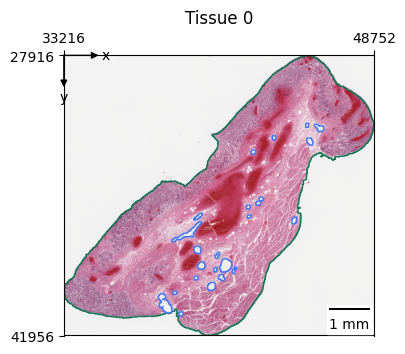

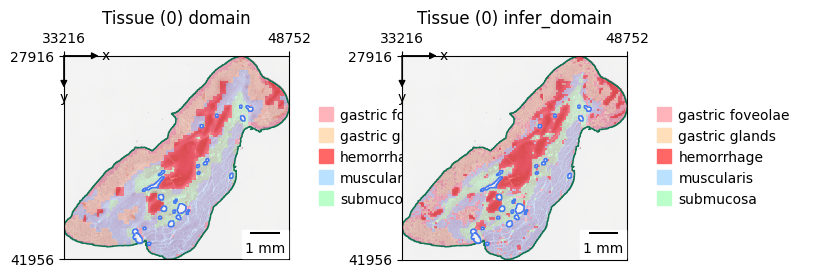

In [12]:
import lazyslide as zs

zs.pl.tissue(test1, tissue_id=0)

zs.pl.tiles(
    test1,
    color=["domain", "infer_domain"],
    alpha=0.6,
    tissue_id=0,
    palette={
        "gastric foveolae": "#FFB3BA",  # soft pink
        "gastric glands": "#FFDFBA",  # peach
        "hemorrhage": "#FF6666",  # red
        "muscularis": "#BAE1FF",  # light blue
        "submucosa": "#BAFFC9",  # light green
    },
)

## Conclusion

Congratulations! You've successfully built a model that can perform tile prediction to approximate segmentation.

The final step is to save the model for future use. We recommend saving the model as a JIT scripted model when possible, as this allows the model to run in any Python environment or PyTorch runtime.

In [13]:
scripted_model = torch.jit.script(model)
torch.jit.save(scripted_model, "tile_model.pt")

# To load the model back
scripted_model = torch.jit.load("tile_model.pt")